# **Importing the required libraries**

In [ ]:
import os, shutil, numpy as np, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# **Data Loading**

In [ ]:
drive.mount('/content/drive', force_remount=True)

#Copy dataset from Drive to Colab's local SSD for faster I/O during training
LOCAL_PATH = "/content/ADNI_MultiView_Dataset"
if not os.path.exists(LOCAL_PATH):
    shutil.copytree("/content/drive/MyDrive/ADNI_MultiView_Dataset", LOCAL_PATH)


#Hyper-parameters
IMG_SIZE = 224
BATCH_SIZE_SIMCLR = 64
BATCH_SIZE_FUSION = 32
NUM_CLASSES = 2

Mounted at /content/drive


In [ ]:
def load_multiview_dataset(path):
  #Loads dataset and groups images by patient ID, ensuring that each sample has 3 views: axial, sagittal, coronal.
    target_classes = ["AD", "CN"]
    data = []

    for label, cls in enumerate(target_classes):
        cls_path = os.path.join(path, cls)
        if not os.path.exists(cls_path): continue

        patient_dict = {}

         # Loop through all image files
        for file in os.listdir(cls_path):
            if not file.lower().endswith(".png"): continue

             # Extract patient ID from filename
            pid = file.split("_brain_norm_")[0]
            if pid not in patient_dict:
                patient_dict[pid] = {}

            # Assign images to their respective views
            for v in ["axial", "sag", "cor"]:
                if v in file.lower():
                    patient_dict[pid][v] = os.path.join(cls_path, file)

        # Only keep patients with all 3 views
        for pid, views in patient_dict.items():
            if len(views) == 3:
                data.append((views["axial"], views["sag"], views["cor"], label))

    return data, target_classes

# Load train, validation, and test datasets
train_data, CLASS_NAMES = load_multiview_dataset(os.path.join(LOCAL_PATH, "train"))
val_data, _ = load_multiview_dataset(os.path.join(LOCAL_PATH, "val"))
test_data, _ = load_multiview_dataset(os.path.join(LOCAL_PATH, "test"))


## Image Preprocessing

In [ ]:
def load_image(path):
  """Reads, decodes, and resizes an image"""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    return tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

# **SimCLR Data Augmentation**

In [ ]:
simclr_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
    layers.GaussianNoise(0.1)
])

def build_simclr_ds(data):
  """
    Builds dataset for SimCLR:
    Returns pairs of augmented images (v1, v2)
    """
    # Flatten all image paths (ignore labels)
    all_paths = [p for tup in data for p in tup[:3]]

    ds = tf.data.Dataset.from_tensor_slices(all_paths)

    def process(path):
        img = load_image(path)
        img = tf.cast(img, tf.float32) / 255.0

        # Generate two augmented views of same image
        return simclr_augmentation(img, training=True), simclr_augmentation(img, training=True)

    return ds.shuffle(2000).map(process).batch(BATCH_SIZE_SIMCLR).repeat()


# **ResNet50 Backbone(Encoder)**

In [ ]:
# Load pretrained ResNet50 (without classification head)
base_resnet = ResNet50(weights="imagenet", include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Add global pooling to convert feature maps into vectors
encoder = Model(
    base_resnet.input,
    layers.GlobalAveragePooling2D()(base_resnet.output),
    name="Encoder"
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


# **Loss Function (NT-XENT)**

In [ ]:
def nt_xent_loss(z1, z2, temperature=0.5):

    # Normalize embeddings
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)

    batch_size = tf.shape(z1)[0]

    # Similarity matrices
    sim_11 = tf.matmul(z1, z1, transpose_b=True) / temperature
    sim_22 = tf.matmul(z2, z2, transpose_b=True) / temperature
    sim_12 = tf.matmul(z1, z2, transpose_b=True) / temperature
    sim_21 = tf.matmul(z2, z1, transpose_b=True) / temperature

    # Mask self-similarity
    mask = tf.eye(batch_size) * 1e9

    # Extract positive pairs (diagonal elements)
    positives = tf.concat([
        tf.linalg.diag_part(sim_12),
        tf.linalg.diag_part(sim_21)
    ], axis=0)

    # Combine negatives
    combined_sim_1 = tf.concat([sim_12 - mask, sim_11 - mask], axis=1)
    combined_sim_2 = tf.concat([sim_21 - mask, sim_22 - mask], axis=1)

    negatives = tf.concat([combined_sim_1, combined_sim_2], axis=0)

    # Compute loss
    loss = -positives + tf.reduce_logsumexp(negatives, axis=1)
    return tf.reduce_mean(loss)


# **SimCLR Model**

In [ ]:
class SimCLR(Model):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

        # Projection head (MLP)
        self.projection = tf.keras.Sequential([
            layers.Dense(512, use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dense(128, use_bias=False),
            layers.BatchNormalization()
        ])

    def train_step(self, data):
        v1, v2 = data

        with tf.GradientTape() as tape:

            # Generate embeddings
            z1 = self.projection(self.encoder(v1, training=True))
            z2 = self.projection(self.encoder(v2, training=True))

            # Compute contrastive loss
            loss = nt_xent_loss(z1, z2)

        # Backpropagation
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {"loss": loss}


In [ ]:
# Compile and train SimCLR
simclr_model = SimCLR(encoder)
simclr_model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5))

print(" Training SimCLR...")
simclr_model.fit(
    build_simclr_ds(train_data),
    epochs=10,
    steps_per_epoch=len(train_data)*3 // BATCH_SIZE_SIMCLR
)

 Training SimCLR...
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - loss: 0.0000e+00
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - loss: 0.0000e+00
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss: 0.0000e+00
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - loss: 0.0000e+00
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss: 0.0000e+00
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - loss: 0.0000e+00
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss: 0.0000e+00
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - loss: 0.0000e+00
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss: 0.0000e+00
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - loss: 0.0000e+00


# **Fusion Data Preparation**

In [ ]:
def augment(img):

    #Augmentation for supervised training
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img

def process_fusion(axial, sag, cor, label):

    #Prepare 3-view input for fusion model
    def prep(p):
        img = load_image(p)
        img = augment(img)
        return preprocess_input(img)

    return {
        "axial_input": prep(axial),
        "sagittal_input": prep(sag),
        "coronal_input": prep(cor)
    }, label

def build_fusion_ds(data, training=True):

    #Build dataset for multi-view supervised training
    ax = tf.constant([x[0] for x in data])
    sg = tf.constant([x[1] for x in data])
    cr = tf.constant([x[2] for x in data])
    lbl = tf.constant([x[3] for x in data])

    ds = tf.data.Dataset.from_tensor_slices((ax, sg, cr, lbl)).map(process_fusion)

    if training:
        ds = ds.shuffle(1000).repeat()

    return ds.batch(BATCH_SIZE_FUSION).prefetch(tf.data.AUTOTUNE)

# **Finetuning**

In [ ]:
encoder.trainable = True # Unfreeze encoder for fine-tuning

for layer in encoder.layers[:-50]:# Freeze early layers, train deeper layers only
    layer.trainable = False


# **Multi-View Fusion Model**

In [ ]:
# Define inputs for 3 views
in_a = layers.Input(shape=(224,224,3), name="axial_input")
in_s = layers.Input(shape=(224,224,3), name="sagittal_input")
in_c = layers.Input(shape=(224,224,3), name="coronal_input")

def branch(x):
    x = encoder(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return x

# Extract features from each view
feat_a = branch(in_a)
feat_s = branch(in_s)
feat_c = branch(in_c)

# Concatenate features
merged = layers.Concatenate()([feat_a, feat_s, feat_c])

# Classification head
x = layers.BatchNormalization()(merged)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Build final model
final_model = Model(inputs=[in_a, in_s, in_c], outputs=outputs)


# **Compile model**

In [ ]:

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# **Training**

In [ ]:
print(" Training Fusion Model...")

history = final_model.fit(
    build_fusion_ds(train_data, True),
    validation_data=build_fusion_ds(val_data, False),
    epochs=50,
    steps_per_epoch=len(train_data)//BATCH_SIZE_FUSION,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
    ]
)


 Training Fusion Model...
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.6250 - loss: 3.0599 - val_accuracy: 0.6891 - val_loss: 2.7801 - learning_rate: 1.0000e-04
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 439ms/step - accuracy: 0.7134 - loss: 2.7984 - val_accuracy: 0.6807 - val_loss: 2.6852 - learning_rate: 1.0000e-04
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 430ms/step - accuracy: 0.7823 - loss: 2.6098 - val_accuracy: 0.7059 - val_loss: 2.6608 - learning_rate: 1.0000e-04
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 432ms/step - accuracy: 0.8244 - loss: 2.4757 - val_accuracy: 0.6975 - val_loss: 2.6001 - learning_rate: 1.0000e-04
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 435ms/step - accuracy: 0.8567 - loss: 2.3302 - val_accuracy: 0.7143 - val_loss: 2.5929 - learning_rate: 1.0000e-04
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 438ms/step - accuracy: 0.8922 - loss: 2.2241 - val_accuracy: 0.7059 - val_loss: 2.7872 - learning_rate: 1.0000e-04
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━

# **Evaluation**


 FINAL REPORT
              precision    recall  f1-score   support

          AD       0.74      0.71      0.72        48
          CN       0.81      0.84      0.82        73

    accuracy                           0.79       121
   macro avg       0.78      0.77      0.77       121
weighted avg       0.78      0.79      0.78       121



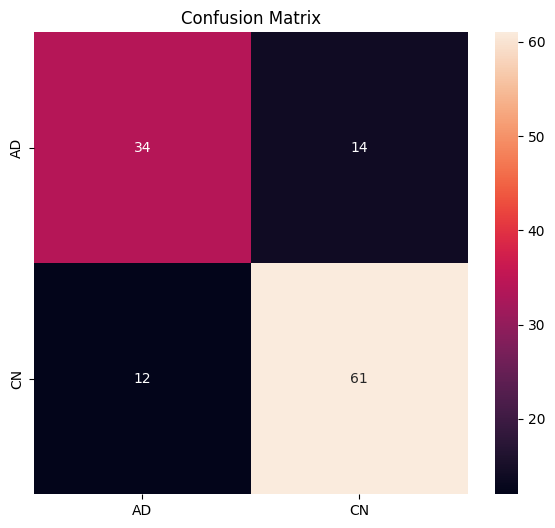

In [ ]:
y_true, y_pred = [], []

for inputs, labels in build_fusion_ds(test_data, False):
    preds = final_model.predict(inputs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n FINAL REPORT")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.show()

# **Saving Feauture Etractor Model**

In [ ]:
# Saving model to Google Drive
model_path = '/content/drive/MyDrive/ADNI_SimCLR_MultiView_Final.h5'
final_model.save(model_path)

print(f"✅ Full model saved to: {model_path}")

✅ Full model saved to: /content/drive/MyDrive/ADNI_SimCLR_MultiView_Final.h5


In [ ]:
# Saving modelweights to Google Drive
weights_path = '/content/drive/MyDrive/ADNI_SimCLR_weights.weights.h5'
final_model.save_weights(weights_path)

print(f"✅ Weights saved to: {weights_path}")

✅ Weights saved to: /content/drive/MyDrive/ADNI_SimCLR_weights.weights.h5
